In [2]:
import numpy as np

import matplotlib.pyplot as plt

In [3]:
# measured_points = np.load('/home/ray/projects/helicopter/notebooks/measured_points.npy')

In [4]:
reference_points = np.array([[ 0.3477,  0.0687, -0.024 ],
 [ 0.3356,  0.0135, -0.0127],
 [ 0.347 ,  0.0544, -0.0219],
 [ 0.3331,  0.0026, -0.034 ],
 [ 0.3353,  0.0268, -0.0276],
 [ 0.3396,  0.0396, -0.0339],
 [ 0.3445,  0.0601, -0.034 ],
 [ 0.3328,  0.0062, -0.0222],
 [ 0.336 ,  0.0334, -0.0169],
 [ 0.3702,  0.1559, -0.049 ]])

In [5]:
reference_mean = reference_points.mean(axis=0)

(-0.12762, 0.07238)

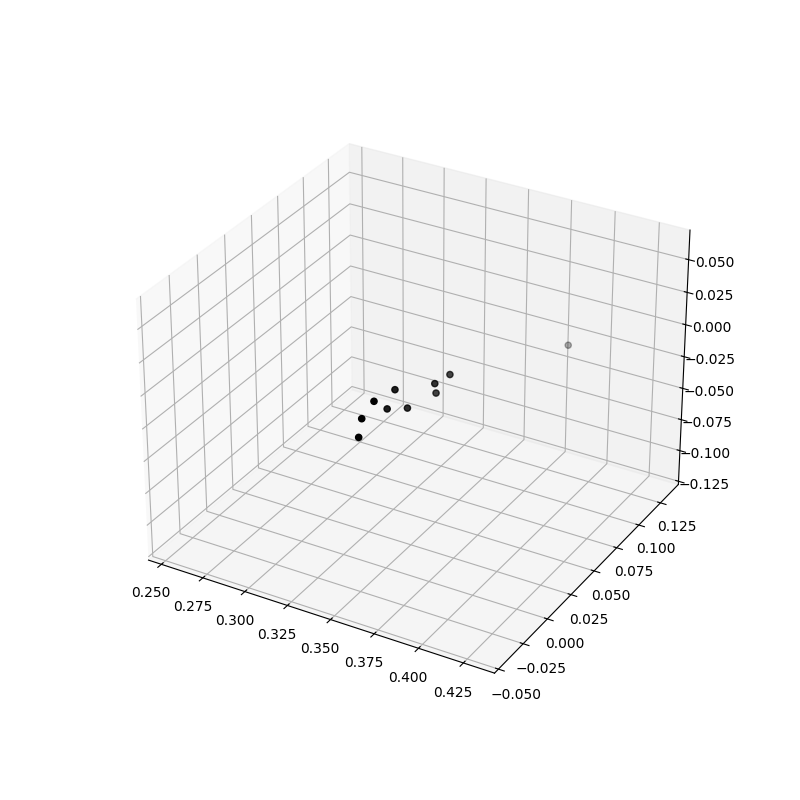

In [6]:
%matplotlib ipympl

plt.close('all')

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')
ax.scatter(reference_points[:, 0], reference_points[:, 1], reference_points[:, 2], color='k')
ax.set_xlim(reference_mean[0] - 0.1, reference_mean[0] + .1)
ax.set_ylim(reference_mean[1] - 0.1, reference_mean[1] + .1)
ax.set_zlim(reference_mean[2] - 0.1, reference_mean[2] + .1)

In [6]:
import quaternion

In [18]:
ref_dist = np.linalg.norm(reference_mean)
q = quaternion.from_rotation_vector([0, 0, np.pi / 2])
t = [ref_dist, -ref_dist, 0]

In [19]:
modified_points = quaternion.rotate_vectors(q, reference_points)
modified_points = modified_points + t

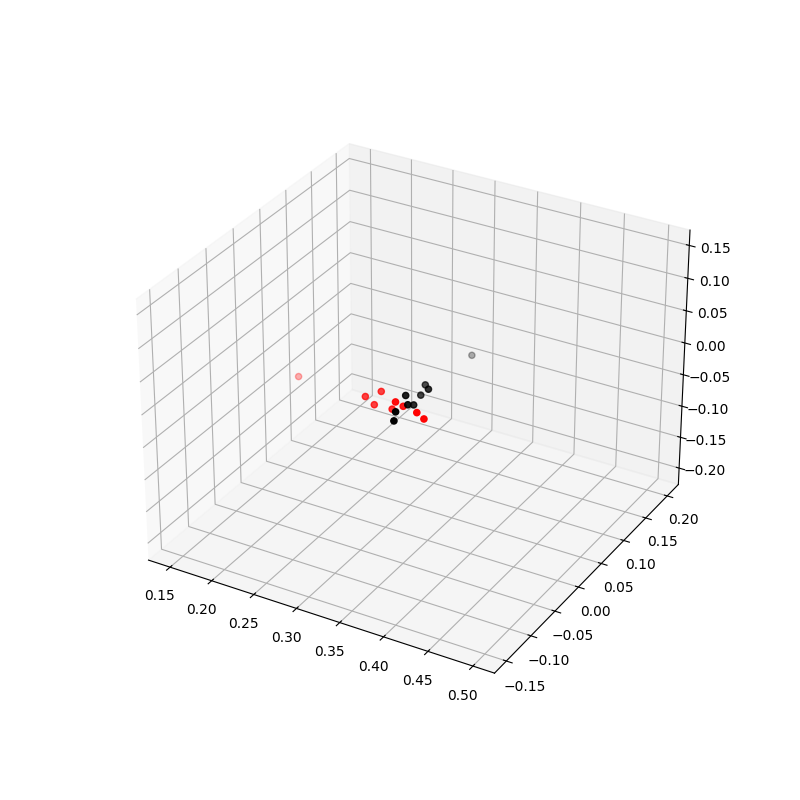

In [20]:
%matplotlib ipympl

plt.close('all')

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')
ax.scatter(reference_points[:, 0], reference_points[:, 1], reference_points[:, 2], color='k')
ax.set_xlim(reference_mean[0] - 0.2, reference_mean[0] + .2)
ax.set_ylim(reference_mean[1] - 0.2, reference_mean[1] + .2)
ax.set_zlim(reference_mean[2] - 0.2, reference_mean[2] + .2)

ax.scatter(modified_points[:, 0], modified_points[:, 1], modified_points[:, 2], color='r')

In [21]:
def kabsch(p: np.ndarray, q: np.ndarray):
    """
    Computes the optimal rotation from measured to reference points, which should capture the camera frame to world frame transformation.
    Args:
        p: matched points in the world frame
        q: points in the camera frame

    Returns:

    """
    n = p.shape[0]
    m_c = np.sum(p, axis=0) / n
    r_c = np.sum(q, axis=0) / n

    measured_points_centered = p - m_c
    reference_points_centered = q - r_c

    covar = measured_points_centered.transpose() @ reference_points_centered
    U, s, Vh = np.linalg.svd(covar)

    rotation_matrix = Vh.T @ U.T

    if np.linalg.det(rotation_matrix) < 0:
        Vh_fixed = Vh.copy()
        Vh_fixed[2, :] *= -1
        rotation_matrix = Vh_fixed.T @ U.T

    translation = r_c - (rotation_matrix @ m_c)

    return rotation_matrix, translation

In [22]:
R, t_pred = kabsch(modified_points, reference_points)
q_pred = quaternion.from_rotation_matrix(R)

In [28]:
from helicopter.vision.measurement.camera_state_handler import CameraStateHandler
csh = CameraStateHandler()

Compiling


In [29]:
success, R_csh, t_csh = CameraStateHandler.ransac_visual_pose(modified_points, reference_points)

In [30]:
q_csh = quaternion.from_rotation_matrix(R_csh)

In [31]:
q_csh

quaternion(0.707106781186548, -2.11798465400005e-16, 3.33066907387547e-16, -0.707106781186547)

In [32]:
t_csh

array([3.25969680e-01, 3.25969680e-01, 1.73472348e-17])

In [36]:
from vision.point_detection.measurement.point_handler import PointHandler
ph = PointHandler()

In [37]:
corrected_points = ph.correct_points(modified_points, t_csh, q_csh)

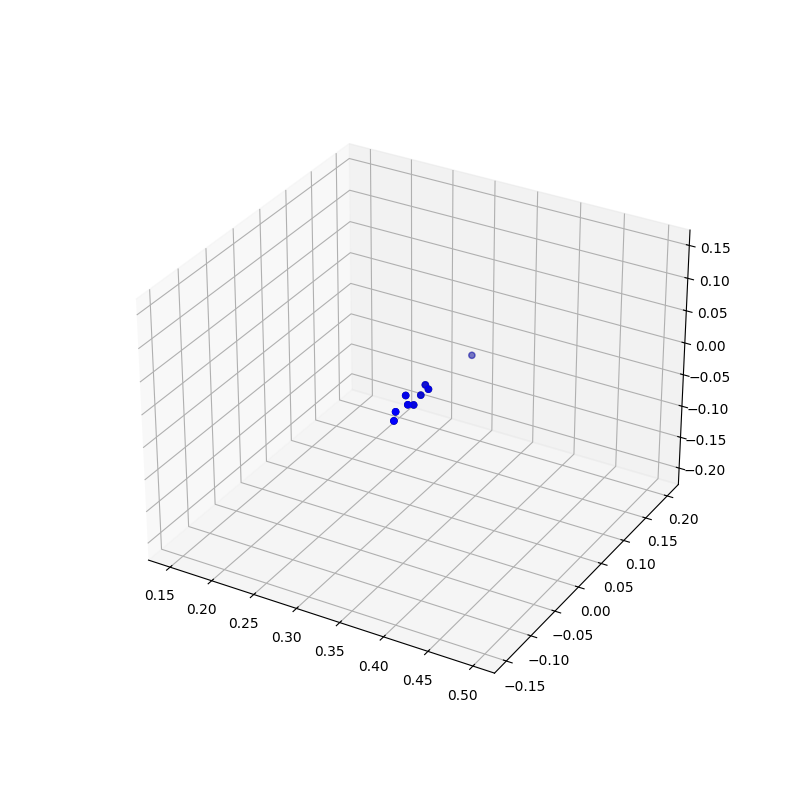

In [38]:
%matplotlib ipympl

plt.close('all')

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')
ax.scatter(reference_points[:, 0], reference_points[:, 1], reference_points[:, 2], color='k')
ax.set_xlim(reference_mean[0] - 0.2, reference_mean[0] + .2)
ax.set_ylim(reference_mean[1] - 0.2, reference_mean[1] + .2)
ax.set_zlim(reference_mean[2] - 0.2, reference_mean[2] + .2)

ax.scatter(corrected_points[:, 0], corrected_points[:, 1], corrected_points[:, 2], color='b')